In [90]:
import pandas as pd
import os
import unicodedata
from datetime import datetime
from pathlib import Path
from datetime import date

# Cargar el archivo
df = pd.read_excel(r"C:\Users\User\Documents\Estudio\Power BI 4.0\caso_fpa_andina_retail_2025.xlsx")
print(f"Filas cargadas: {df.shape[0]}")

# --- Cargar las dos hojas del archivo original ---
df_ventas = pd.read_excel("caso_fpa_andina_retail_2025.xlsx", sheet_name="RAW_Ventas_Real_2025")
df_presupuesto = pd.read_excel("caso_fpa_andina_retail_2025.xlsx", sheet_name="Presupuesto_2025")

# Ver qué tiene la hoja de presupuesto
print(df_presupuesto.head())
print(df_presupuesto.shape)
print(df_presupuesto.columns.tolist())



Filas cargadas: 1620
    Fecha_Mes  Region        Categoria  Presupuesto_Unidades  \
0  2025-01-01   Norte         Hardware                   145   
1  2025-01-01   Norte         Software                   147   
2  2025-01-01   Norte  Servicios Cloud                   159   
3  2025-01-01   Norte       Accesorios                   262   
4  2025-01-01  Centro         Hardware                   253   

   Presupuesto_Ventas_USD  Presupuesto_Costo_USD  Presupuesto_OPEX_USD  
0                   72500                  50750               13050.0  
1                   22050                   4410                3969.0  
2                   31800                   7950                5724.0  
3                   10480                   3930                1886.4  
4                  126500                  88550               22770.0  
(144, 7)
['Fecha_Mes', 'Region', 'Categoria', 'Presupuesto_Unidades', 'Presupuesto_Ventas_USD', 'Presupuesto_Costo_USD', 'Presupuesto_OPEX_USD']


In [91]:
# --- Limpiar hoja de presupuesto ---
df_presupuesto["Fecha_Mes"] = pd.to_datetime(df_presupuesto["Fecha_Mes"], errors="coerce")
df_presupuesto["Region"] = df_presupuesto["Region"].str.strip().str.title()
df_presupuesto["Categoria"] = df_presupuesto["Categoria"].str.strip().str.title()

print("Nulos en presupuesto:")
print(df_presupuesto.isnull().sum())
print(df_presupuesto.head())

Nulos en presupuesto:
Fecha_Mes                 0
Region                    0
Categoria                 0
Presupuesto_Unidades      0
Presupuesto_Ventas_USD    0
Presupuesto_Costo_USD     0
Presupuesto_OPEX_USD      0
dtype: int64
   Fecha_Mes  Region        Categoria  Presupuesto_Unidades  \
0 2025-01-01   Norte         Hardware                   145   
1 2025-01-01   Norte         Software                   147   
2 2025-01-01   Norte  Servicios Cloud                   159   
3 2025-01-01   Norte       Accesorios                   262   
4 2025-01-01  Centro         Hardware                   253   

   Presupuesto_Ventas_USD  Presupuesto_Costo_USD  Presupuesto_OPEX_USD  
0                   72500                  50750               13050.0  
1                   22050                   4410                3969.0  
2                   31800                   7950                5724.0  
3                   10480                   3930                1886.4  
4                  126500

In [93]:

# Unificar ciudad
def normalizar_ciudad(valor):
    if pd.isna(valor):
        return valor
    
    # Quitar espacios
    valor = str(valor).strip()
    
    # Quitar acentos
    valor_sin_acento = ''.join(
        c for c in unicodedata.normalize('NFD', valor)
        if unicodedata.category(c) != 'Mn'
    )
    
    # Comparar en minúsculas
    valor_sin_acento = valor_sin_acento.lower()
    
    # Unificar Bogotá
    if valor_sin_acento == "bogota":
        return "Bogotá"
    
    return valor.title()

df_ventas["Ciudad"] = df_ventas["Ciudad"].apply(normalizar_ciudad)
    
    # Unificar región
def normalizar_Region(valor):
    if pd.isna(valor):
        return valor

    # Quitar espacios
    valor = str(valor).strip()

    # Quitar acentos
    valor_sin_acento = ''.join(
        c for c in unicodedata.normalize('NFD', valor)
        if unicodedata.category(c) != 'Mn'
    )

    # Comparar en minúsculas
    valor_sin_acento = valor_sin_acento.lower()

    return valor.title()

df_ventas["Region"] = df_ventas["Region"].apply(normalizar_Region)

# Convertir Ventas_Totales_USD a número (CANCELADO se convierte en 0)
df_ventas["Ventas_Totales_USD"] = pd.to_numeric(df_ventas["Ventas_Totales_USD"], errors="coerce").fillna(0)

# Convertir Unidades a número (PENDIENTE se convierte en 0)
df_ventas["Unidades"] = pd.to_numeric(df_ventas["Unidades"], errors="coerce").fillna(0)

# Convertir Unidades a número (N/A se convierte en 0)
df_ventas["Precio_Unitario_USD"] = pd.to_numeric(df_ventas["Precio_Unitario_USD"], errors="coerce").fillna(0)

# Ahora sí puedes ver negativos en ventas
print("Ventas negativas:")
print(df_ventas[df_ventas["Ventas_Totales_USD"] < 0])

# Precios negativos se convierten a positivos (error de digitación)
df["Precio_Unitario_USD"] = pd.to_numeric(df["Precio_Unitario_USD"], errors="coerce").abs()

# Rellenar nulos de precio con la mediana de su categoría
df_ventas["Precio_Unitario_USD"] = df_ventas.groupby("Categoria")["Precio_Unitario_USD"].transform(
    lambda x: x.fillna(x.median())
)

# Eliminar filas con ventas negativas o canceladas (NaN)
df_ventas = df_ventas[df_ventas["Ventas_Totales_USD"] > 0]
    
# Confirmar que no quedan negativos ni nulos
print(f"Negativos en ventas: {(df_ventas['Ventas_Totales_USD'] < 0).sum()}")
print(f"Nulos restantes:\n{df_ventas.isnull().sum()}")





# --- Eliminar filas con valores nulos en columnas clave ---
df_ventas = df_ventas.dropna(subset=["Fecha", "Ventas_Totales_USD", "Region", "Categoria"])


Ventas negativas:
Empty DataFrame
Columns: [ID_Transaccion, Fecha, Ciudad, Region, Categoria, Unidades, Precio_Unitario_USD, Ventas_Totales_USD, Costo_Total_USD, Estado_Pago]
Index: []
Negativos en ventas: 0
Nulos restantes:
ID_Transaccion         0
Fecha                  0
Ciudad                 0
Region                 0
Categoria              0
Unidades               0
Precio_Unitario_USD    0
Ventas_Totales_USD     0
Costo_Total_USD        0
Estado_Pago            0
dtype: int64


In [87]:
# Arreglar fechas con dos formatos diferentes ---
# Guardamos el texto original para intentar dos conversiones
df_ventas["Fecha_original"] = df_ventas["Fecha"].astype(str)

# Intento 1: formato 2025-09-26
df_ventas["Fecha"] = pd.to_datetime(df_ventas["Fecha"], dayfirst=True, errors="coerce")

# Intento 2: formato 26/09/2025 (para las que fallaron)
mascara = df_ventas["Fecha"].isnull()
df_ventas.loc[mascara, "Fecha"] = pd.to_datetime(
    df_ventas.loc[mascara, "Fecha_original"], format="%d/%m/%Y", errors="coerce"
)

# Eliminar columna auxiliar
df_ventas = df_ventas.drop(columns=["Fecha_original"])

In [ ]:
# Primeras 5 filas
print(df_ventas.head())

# Dimensiones: filas x columnas
print(df_ventas.shape)

# Tipos de datos de cada columna
print(df_ventas.dtypes)

# Resumen estadístico
print(df_ventas.describe())

# ¿Cuántos valores nulos hay por columna?
print(df_ventas.isnull().sum())

# ¿Cuántos valores únicos tiene la columna Ciudad?
print(df_ventas["Ciudad"].unique())

# ¿Cuántos valores únicos tiene la columna Region?
print(df_ventas["Region"].unique())

# Valores negativos en precios
print(df_ventas[df_ventas["Precio_Unitario_USD"] < 0])

# Valores negativos en ventas
print(df_ventas[df_ventas["Ventas_Totales_USD"] < 0])

In [ ]:
# Guardar archivo limpio con fecha de hoy
ruta = Path(r"C:\Users\User\Documents\Estudio\Power BI 4.0")

# Fecha de hoy
hoy = datetime.today().strftime("%d%m%Y")

archivo_salida = ruta / f"andina_retail_modelo_{hoy}.xlsx"

# Guardar el DataFrame df YA LIMPIO
df_ventas.to_excel(archivo_salida, index=False)

# solo cambia el nombre del archivo 
print(f"✅ Archivo guardado correctamente en:")
print(archivo_salida)



In [75]:

# Expotar archivo con las dos hojas de datos

# Fecha de hoy
hoy = datetime.today().strftime("%d%m%Y")
ruta_historial = rf"C:\Users\User\Documents\Estudio\Power BI 4.0\andina_retail_modelo_{hoy}.xlsx"

# Archivo fijo para Power BI
ruta_powerbi = r"C:\Users\User\Documents\Estudio\Power BI 4.0\andina_retail_modelo.xlsx"

with pd.ExcelWriter(ruta_historial, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Fact_VentasReal", index=False)
    df_presupuesto.to_excel(writer, sheet_name="Fact_Presupuesto", index=False)

with pd.ExcelWriter(ruta_powerbi, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Fact_VentasReal", index=False)
    df_presupuesto.to_excel(writer, sheet_name="Fact_Presupuesto", index=False)

print(f"Guardado historial: andina_retail_modelo_{hoy}.xlsx")
print(f"Guardado Power BI: andina_retail_modelo.xlsx")

Guardado historial: andina_retail_modelo_25092026.xlsx
Guardado Power BI: andina_retail_modelo.xlsx


In [53]:
# Ver las filas donde Fecha quedó nula
print(df_ventas[df_ventas["Fecha"].isnull()][["ID_Transaccion", "Fecha"]].head(20))


Empty DataFrame
Columns: [ID_Transaccion, Fecha]
Index: []


In [54]:
# ¿Cuántos formatos diferentes hay en el archivo original?
# Recarga el original solo para ver
df_original = pd.read_excel(r"C:\Users\User\Documents\Estudio\Power BI 4.0\caso_fpa_andina_retail_2025.xlsx")
fechas_problemas = df_original[df_original["ID_Transaccion"].isin(
    df_ventas[df_ventas["Fecha"].isnull()]["ID_Transaccion"]
)]

print(fechas_problemas[["ID_Transaccion", "Fecha"]])

Empty DataFrame
Columns: [ID_Transaccion, Fecha]
Index: []


In [55]:
#Consutar SQL

import sqlite3

# --- Crear una base de datos en memoria ---
conexion = sqlite3.connect(":memory:")

# --- Cargar tu dataset limpio como tabla SQL ---
df_ventas.to_sql("ventas", conexion, index=False, if_exists="replace")

print("Base de datos lista. Tabla 'ventas' creada.")



Base de datos lista. Tabla 'ventas' creada.


In [ ]:
# --- Función para ejecutar consultas SQL fácilmente ---
def consultar(sql):
    return pd.read_sql(sql, conexion)

# --- CONSULTA 1: Ver las primeras 5 filas ---
consultar("SELECT * FROM ventas LIMIT 5")

In [ ]:
# --- CONSULTA 2: Total de ventas por categoria ---
consultar("""
    SELECT 
        Categoria,
        COUNT(*) AS total_transacciones,
        ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales
    FROM ventas
    GROUP BY Categoria
    ORDER BY ventas_totales DESC
    """)

In [56]:
# --- CONSULTA 3: Ventas por region ---
consultar("""
    SELECT 
        Region,
        ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales,
        ROUND(AVG(Ventas_Totales_USD), 2) AS ticket_promedio
    FROM ventas
    GROUP BY Region
    ORDER BY ventas_totales DESC
""")

,Region,ventas_totales,ticket_promedio
0,Centro,1767807.0,3069.11
1,Norte,1684153.0,2734.01
2,Sur,1272979.5,3255.70


In [57]:
# --- CONSULTA 4: Top 5 meses con mas ventas ---
consultar("""
    SELECT 
        SUBSTR(Fecha, 1, 7) AS mes,
        ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales
    FROM ventas
    GROUP BY mes
    ORDER BY ventas_totales DESC
    LIMIT 5
""")

,mes,ventas_totales
0,2025-07,531156.0
1,2025-01,458931.0
2,2025-04,446696.0
3,2025-06,431219.0
4,2025-12,417344.5


In [58]:
# --- CONSULTA 5: Margen de ganancia por categoria ---
consultar("""
    SELECT 
        Categoria,
        ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales,
        ROUND(SUM(Costo_Total_USD), 2) AS costo_total,
        ROUND(SUM(Ventas_Totales_USD) - SUM(Costo_Total_USD), 2) AS ganancia,
        ROUND(
            (SUM(Ventas_Totales_USD) - SUM(Costo_Total_USD)) 
            / SUM(Ventas_Totales_USD) * 100, 1
        ) AS margen_pct
    FROM ventas
    GROUP BY Categoria
    ORDER BY margen_pct DESC
""")

,Categoria,ventas_totales,costo_total,ganancia,margen_pct
0,Software,853807.5,177990.0,675817.5,79.2
1,Servicios Cloud,996990.0,260200.0,736790.0,73.9
2,Accesorios,112192.0,43920.0,68272.0,60.9
3,Hardware,2761950.0,2150837.5,611112.5,22.1


In [59]:
# --- CONSULTA 6: Margen por region ---
consultar("""
    SELECT 
        Region,
        ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales,
        ROUND(SUM(Ventas_Totales_USD) - SUM(Costo_Total_USD), 2) AS ganancia,
        ROUND(
            (SUM(Ventas_Totales_USD) - SUM(Costo_Total_USD)) 
            / SUM(Ventas_Totales_USD) * 100, 1
        ) AS margen_pct
    FROM ventas
    GROUP BY Region
    ORDER BY margen_pct DESC
""")

,Region,ventas_totales,ganancia,margen_pct
0,Norte,1684153.0,786118.0,46.7
1,Sur,1272979.5,547504.5,43.0
2,Centro,1767807.0,758369.5,42.9


In [60]:
# --- Guardar consultas SQL en archivo de portafolio ---
sql_portafolio = """
-- =============================================
-- ANÁLISIS ANDINA RETAIL 2025
-- Autor: [NATALIA BERMUDEZ]
-- =============================================

-- 1. Ventas por categoría
SELECT 
    Categoria,
    COUNT(*) AS total_transacciones,
    ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales
FROM ventas
GROUP BY Categoria
ORDER BY ventas_totales DESC;

-- 2. Ventas por región
SELECT 
    Region,
    ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales,
    ROUND(AVG(Ventas_Totales_USD), 2) AS ticket_promedio
FROM ventas
GROUP BY Region
ORDER BY ventas_totales DESC;

-- 3. Margen de ganancia por categoría
SELECT 
    Categoria,
    ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales,
    ROUND(SUM(Costo_Total_USD), 2) AS costo_total,
    ROUND(SUM(Ventas_Totales_USD) - SUM(Costo_Total_USD), 2) AS ganancia,
    ROUND(
        (SUM(Ventas_Totales_USD) - SUM(Costo_Total_USD)) 
        / SUM(Ventas_Totales_USD) * 100, 1
    ) AS margen_pct
FROM ventas
GROUP BY Categoria
ORDER BY margen_pct DESC;

-- 4. Margen por región
SELECT 
    Region,
    ROUND(SUM(Ventas_Totales_USD), 2) AS ventas_totales,
    ROUND(SUM(Ventas_Totales_USD) - SUM(Costo_Total_USD), 2) AS ganancia,
    ROUND(
        (SUM(Ventas_Totales_USD) - SUM(Costo_Total_USD)) 
        / SUM(Ventas_Totales_USD) * 100, 1
    ) AS margen_pct
FROM ventas
GROUP BY Region
ORDER BY margen_pct DESC;
"""

with open("consultas_andina_retail.sql", "w", encoding="utf-8") as f:
    f.write(sql_portafolio)

print("Archivo SQL guardado en tu carpeta")

Archivo SQL guardado en tu carpeta


In [61]:

# instala la librería que necesitas
! pip install matplotlib seaborn

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Estilo general de todas las gráficas ---
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid")

print("Librerías listas")

Librerías listas


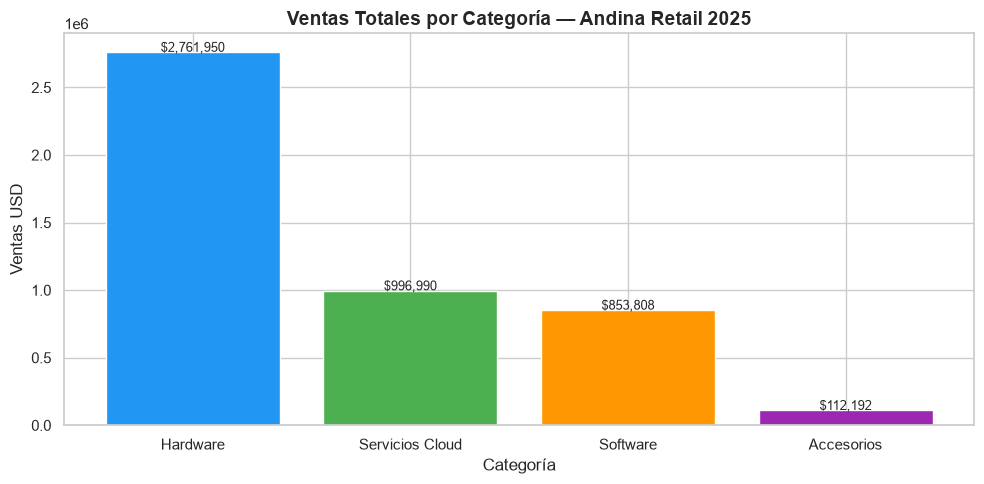

Gráfica guardada


In [64]:
# --- GRÁFICA 1: Ventas totales por categoría ---

# Preparar los datos
ventas_categoria = df_ventas.groupby("Categoria")["Ventas_Totales_USD"].sum().sort_values(ascending=False).reset_index()

# Crear la gráfica
fig, ax = plt.subplots()

barras = ax.bar(
    ventas_categoria["Categoria"],
    ventas_categoria["Ventas_Totales_USD"],
    color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
)

# --- Títulos y etiquetas ---
ax.set_title("Ventas Totales por Categoría — Andina Retail 2025", fontsize=14, fontweight="bold")
ax.set_xlabel("Categoría")
ax.set_ylabel("Ventas USD")

# --- Valor encima de cada barra ---
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 1000,
        f"${altura:,.0f}",
        ha="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("grafica_ventas_categoria.png", dpi=150)
plt.show()

print("Gráfica guardada")

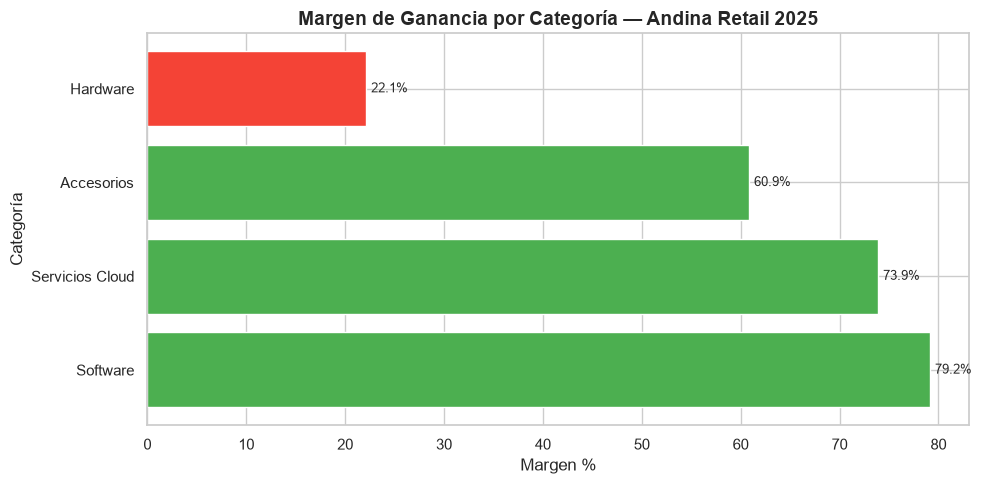

Gráfica guardada


In [65]:
# --- GRÁFICA 2: Margen de ganancia por categoría ---

# Preparar los datos
margen = df_ventas.groupby("Categoria").apply(
    lambda x: (x["Ventas_Totales_USD"].sum() - x["Costo_Total_USD"].sum()) 
    / x["Ventas_Totales_USD"].sum() * 100
).sort_values(ascending=False).reset_index()
margen.columns = ["Categoria", "Margen_Pct"]

# Crear la gráfica
fig, ax = plt.subplots()

barras = ax.barh(
    margen["Categoria"],
    margen["Margen_Pct"],
    color=["#4CAF50" if v > 50 else "#FF9800" if v > 30 else "#F44336" 
           for v in margen["Margen_Pct"]]
)

# --- Títulos ---
ax.set_title("Margen de Ganancia por Categoría — Andina Retail 2025", fontsize=14, fontweight="bold")
ax.set_xlabel("Margen %")
ax.set_ylabel("Categoría")

# --- Valor al lado de cada barra ---
for barra in barras:
    ancho = barra.get_width()
    ax.text(
        ancho + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{ancho:.1f}%",
        va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("grafica_margen_categoria.png", dpi=150)
plt.show()

print("Gráfica guardada")

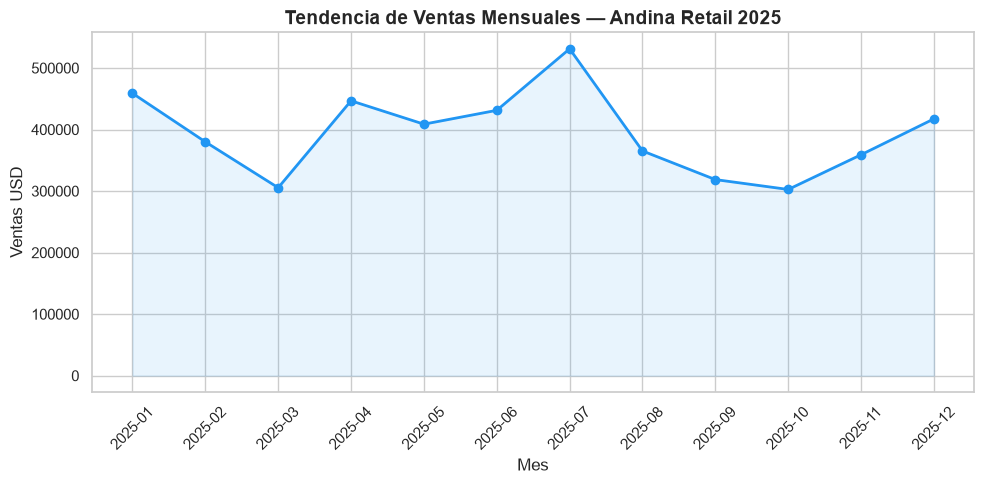

Gráfica guardada


In [67]:
# --- GRÁFICA 3: Ventas por mes ---

# Preparar los datos
df_ventas["Mes"] = df_ventas["Fecha"].dt.to_period("M").astype(str)
ventas_mes = df_ventas.groupby("Mes")["Ventas_Totales_USD"].sum().reset_index()
ventas_mes = ventas_mes.sort_values("Mes")

# Crear la gráfica
fig, ax = plt.subplots()

ax.plot(
    ventas_mes["Mes"],
    ventas_mes["Ventas_Totales_USD"],
    marker="o",
    color="#2196F3",
    linewidth=2,
    markersize=6
)

# --- Sombrear área bajo la línea ---
ax.fill_between(
    ventas_mes["Mes"],
    ventas_mes["Ventas_Totales_USD"],
    alpha=0.1,
    color="#2196F3"
)

# --- Títulos ---
ax.set_title("Tendencia de Ventas Mensuales — Andina Retail 2025", fontsize=14, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Ventas USD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("grafica_ventas_mes.png", dpi=150)
plt.show()

print("Gráfica guardada")

Archivo exportado con las dos hojas listo
